# Benchmarking Notebook

Benchmarking **DFS** and **A*** on **Sudoku** and **Net** (pipes) puzzles at various sizes / difficulties. 
This version iterates over available heuristics for A*.

## 1 · Setup

In [9]:
# Clone repo (skip if already cloned)
import os
if not os.path.isdir('IntroAiAssignment1'):
    !git clone git@github.com:namanhishere/IntroAiAssignment1.git

In [10]:
!pip install -q -r ./IntroAiAssignment1/requirements.txt
!pip install -q psutil py-cpuinfo matplotlib pandas tabulate

In [11]:
import sys, os
sys.path.insert(0, os.path.abspath("IntroAiAssignment1"))

In [12]:
from algorithms.dfs import DFS
from algorithms.astar import AStar
from domain import SudokuProblem, NetProblem
from generator.create_sodoku import generate_sudoku_puzzle
from generator.create_net import generate_net_puzzle

In [13]:
import json
import random
import numpy as np
import time
import tracemalloc
import gc
import os
import signal
import concurrent.futures
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from tabulate import tabulate

matplotlib.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

## 2 · System Information

In [14]:
import platform, psutil
try:
    from cpuinfo import get_cpu_info
    cpu_name = get_cpu_info()['brand_raw']
except Exception:
    cpu_name = platform.processor()

print("-" * 40)
print("SYSTEM BENCHMARK METADATA")
print("-" * 40)
print(f"OS             : {platform.system()} {platform.release()} ({platform.architecture()[0]})")
print(f"Python Version : {platform.python_version()}")
print(f"CPU Model      : {cpu_name}")
print(f"Physical Cores : {psutil.cpu_count(logical=False)}")
print(f"Total Threads  : {psutil.cpu_count(logical=True)}")
cpufreq = psutil.cpu_freq()
if cpufreq:
    print(f"Max Frequency  : {cpufreq.max:.2f} MHz")
svmem = psutil.virtual_memory()
print(f"Total RAM      : {svmem.total / (1024**3):.2f} GB")
print("-" * 40)

----------------------------------------
SYSTEM BENCHMARK METADATA
----------------------------------------
OS             : Linux 6.17.0-14-generic (64bit)
Python Version : 3.12.3
CPU Model      : 12th Gen Intel(R) Core(TM) i7-12700H
Physical Cores : 14
Total Threads  : 20
Max Frequency  : 4180.00 MHz
Total RAM      : 38.87 GB
----------------------------------------


## 3 · Benchmark Helper

In [15]:
# ── Benchmark configuration ───────────────────────────────────────────────────
TIMEOUT        = 120          # seconds per single algorithm run
WARMUP_RUNS    = 2            # warm-up runs (recorded but not counted in avg)
BENCHMARK_RUNS = 10           # timed runs whose average is reported
NUM_WORKERS    = os.cpu_count()  # use ALL logical cores

RESULTS_DIR = "benchmark_output"
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"⚙️  Workers        : {NUM_WORKERS}")
print(f"⚙️  Warmup runs    : {WARMUP_RUNS}  (saved but excluded from avg)")
print(f"⚙️  Benchmark runs : {BENCHMARK_RUNS}  (averaged)")
print(f"⚙️  Timeout/run    : {TIMEOUT}s")
print(f"📁 Output dir      : {RESULTS_DIR}/")


# ── Grid serialisation helper ─────────────────────────────────────────────────
def _grid_to_json(grid, problem_type: str) -> str:
    """Serialise a puzzle grid to a compact JSON string."""
    if problem_type == "Sudoku":
        return json.dumps(grid)
    # Net: List[List[Tuple[PipeType(IntEnum), int]]]  →  nested int lists
    return json.dumps([[[int(pt), rot] for pt, rot in row] for row in grid])


# ── Subprocess worker (top-level so it is picklable for ProcessPoolExecutor) ──
def _benchmark_worker(task_spec: dict) -> dict:
    """
    Runs inside a worker process (forked on Linux).
    1. WARMUP_RUNS runs  → recorded with run_type="warmup", excluded from avg
    2. BENCHMARK_RUNS runs → recorded with run_type="benchmark", averaged
    Uses SIGALRM for per-run timeout (Linux / macOS).

    Returns summary dict including a 'per_run_results' list with one entry
    per individual run (warmup + benchmark).
    """
    import sys, os, gc, time, tracemalloc, signal

    proj_dir = task_spec["proj_dir"]
    if proj_dir not in sys.path:
        sys.path.insert(0, proj_dir)

    from algorithms.dfs import DFS
    from algorithms.astar import AStar
    from domain.sudoku_problem import SudokuProblem
    from domain.net_problem import NetProblem

    _timeout = task_spec["timeout"]

    class _Timeout(Exception):
        pass

    def _handler(sig, frame):
        raise _Timeout()

    def _make_algo():
        return DFS() if task_spec["algo_name"] == "DFS" else AStar()

    def _make_problem():
        grid = task_spec["grid"]
        h    = task_spec.get("heuristic")
        if task_spec["problem_type"] == "Sudoku":
            return SudokuProblem(grid, heuristic=h) if h else SudokuProblem(grid)
        return NetProblem(grid, heuristic=h) if h else NetProblem(grid)

    def _run_once():
        gc.collect()
        algo    = _make_algo()
        problem = _make_problem()
        old = signal.signal(signal.SIGALRM, _handler)
        signal.alarm(_timeout)
        tracemalloc.start()
        t0        = time.perf_counter()
        timed_out = False
        goal      = None
        try:
            goal = algo.solve_benchmark(problem)
        except _Timeout:
            timed_out = True
        finally:
            t1 = time.perf_counter()
            signal.alarm(0)
            signal.signal(signal.SIGALRM, old)
            if tracemalloc.is_tracing():
                _, peak = tracemalloc.get_traced_memory()
                tracemalloc.stop()
            else:
                peak = 0
        gc.collect()
        return {
            "solved":         not timed_out and goal is not None,
            "timed_out":      timed_out,
            "time_s":         round(t1 - t0, 6),
            "steps":          algo.step_count,
            "path_length":    len(goal.solution()) if goal is not None else None,
            "peak_memory_mb": round(peak / 1024 / 1024, 4),
        }

    # ── warmup ────────────────────────────────────────────────────────────────
    warmup_records = []
    for wu_idx in range(task_spec["warmup_runs"]):
        try:
            r = _run_once()
            warmup_records.append({"run_type": "warmup", "run_idx": wu_idx, **r})
            if r["timed_out"]:          # problem too slow → skip bench entirely
                return {
                    "solved": False, "solved_count": 0, "bench_runs": 0,
                    "timed_out": True,  "time_s": float(_timeout),
                    "steps": r["steps"], "path_length": None,
                    "peak_memory_mb": r["peak_memory_mb"],
                    "per_run_results": warmup_records,
                }
        except Exception as exc:
            warmup_records.append({
                "run_type": "warmup", "run_idx": wu_idx,
                "solved": False, "timed_out": False,
                "time_s": None, "steps": None,
                "path_length": None, "peak_memory_mb": None,
                "error": str(exc),
            })
        gc.collect()

    # ── benchmark runs ────────────────────────────────────────────────────────
    bench_records = []
    for b_idx in range(task_spec["bench_runs"]):
        try:
            r = _run_once()
            bench_records.append({"run_type": "benchmark", "run_idx": b_idx, **r})
            if r["timed_out"]:
                break           # further runs will also time out → stop early
        except Exception as exc:
            bench_records.append({
                "run_type": "benchmark", "run_idx": b_idx,
                "solved": False, "timed_out": False,
                "time_s": None, "steps": None,
                "path_length": None, "peak_memory_mb": None,
                "error": str(exc),
            })
        gc.collect()

    per_run_results = warmup_records + bench_records

    if not bench_records:
        return {
            "solved": False, "solved_count": 0, "bench_runs": 0,
            "timed_out": False, "time_s": None, "steps": None,
            "path_length": None, "peak_memory_mb": None,
            "error": "all benchmark runs failed",
            "per_run_results": per_run_results,
        }

    n            = len(bench_records)
    any_to       = any(r.get("timed_out") for r in bench_records)
    solved_count = sum(1 for r in bench_records if r.get("solved"))

    def _avg(key):
        vals = [r[key] for r in bench_records if r.get(key) is not None]
        return sum(vals) / len(vals) if vals else None

    avg_time  = _avg("time_s")
    avg_steps = _avg("steps")
    avg_mem   = _avg("peak_memory_mb")
    avg_pl    = _avg("path_length")

    return {
        "solved":         solved_count == n and not any_to,
        "solved_count":   solved_count,
        "bench_runs":     n,
        "timed_out":      any_to,
        "time_s":         round(avg_time,  6) if avg_time  is not None else None,
        "steps":          round(avg_steps, 2) if avg_steps is not None else None,
        "path_length":    round(avg_pl,    2) if avg_pl    is not None else None,
        "peak_memory_mb": round(avg_mem,   4) if avg_mem   is not None else None,
        "per_run_results": per_run_results,
    }


# ── Parallel task runner ───────────────────────────────────────────────────────
_PROJ_DIR = os.path.abspath("IntroAiAssignment1")


def run_tasks_parallel(task_list: list) -> list:
    """
    Submits all (meta, spec) tuples to ProcessPoolExecutor(max_workers=NUM_WORKERS).
    Results are printed as they arrive (via as_completed) and returned in
    the same order as task_list.
    """
    results = [None] * len(task_list)

    with concurrent.futures.ProcessPoolExecutor(max_workers=NUM_WORKERS) as executor:
        future_to_idx = {
            executor.submit(_benchmark_worker, spec): i
            for i, (_, spec) in enumerate(task_list)
        }

        for future in concurrent.futures.as_completed(future_to_idx):
            i    = future_to_idx[future]
            meta = task_list[i][0]
            try:
                res = future.result()
            except Exception as exc:
                res = {
                    "solved": False, "timed_out": False,
                    "time_s": None,  "steps": None,
                    "path_length": None, "peak_memory_mb": None,
                    "per_run_results": [],
                    "error": str(exc),
                }
            tag = "✅" if res.get("solved") else ("⏱ TIMEOUT" if res.get("timed_out") else "❌")
            n_runs = len([r for r in res.get("per_run_results", []) if r.get("run_type") == "benchmark"])
            print(
                f"  {meta['algo_display']:30s} | {meta['label']:35s} → {tag}"
                f"  avg_time={res.get('time_s')}s  avg_steps={res.get('steps')}"
                f"  ({n_runs} bench runs)"
            )
            results[i] = (meta, res)
            gc.collect()

    return results

⚙️  Workers        : 20
⚙️  Warmup runs    : 2  (saved but excluded from avg)
⚙️  Benchmark runs : 10  (averaged)
⚙️  Timeout/run    : 120s
📁 Output dir      : benchmark_output/


### Algorithm Registry

In [16]:
ALGORITHMS = {
    'DFS': lambda: DFS(),
    'A*':  lambda: AStar(),
}

---
## 4 · Sudoku Benchmark

### 4.1 Generate Sudoku Puzzles

Different difficulty = different number of cells removed.

In [17]:
SUDOKU_LEVELS = {
    'Easy (30)':   30,
    'Medium (40)': 40,
    'Hard (50)':   50,
    'Max':         'max',
}

NUM_SUDOKU_TRIALS = 3

sudoku_puzzles = {}  # level_name -> list of (grid, seed)

for level_name, level_val in SUDOKU_LEVELS.items():
    puzzles = []
    for trial in range(NUM_SUDOKU_TRIALS):
        seed = 1000 + trial
        grid = generate_sudoku_puzzle(seed=seed, level=level_val)
        clues = sum(1 for row in grid for c in row if c != 0)
        puzzles.append((grid, seed))
        print(f"  {level_name} trial {trial}: {clues} clues  (seed={seed})")
    sudoku_puzzles[level_name] = puzzles
    print()

print("✅ Sudoku puzzle generation complete.")

--> Removed 30 cells.
  Easy (30) trial 0: 51 clues  (seed=1000)
--> Removed 30 cells.
  Easy (30) trial 1: 51 clues  (seed=1001)
--> Removed 30 cells.
  Easy (30) trial 2: 51 clues  (seed=1002)

--> Removed 40 cells.
  Medium (40) trial 0: 41 clues  (seed=1000)
--> Removed 40 cells.
  Medium (40) trial 1: 41 clues  (seed=1001)
--> Removed 40 cells.
  Medium (40) trial 2: 41 clues  (seed=1002)

--> Removed 50 cells.
  Hard (50) trial 0: 31 clues  (seed=1000)
--> Removed 50 cells.
  Hard (50) trial 1: 31 clues  (seed=1001)
--> Removed 50 cells.
  Hard (50) trial 2: 31 clues  (seed=1002)

--> Removed 57 cells.
  Max trial 0: 24 clues  (seed=1000)
--> Removed 55 cells.
  Max trial 1: 26 clues  (seed=1001)
--> Removed 57 cells.
  Max trial 2: 24 clues  (seed=1002)

✅ Sudoku puzzle generation complete.


### 4.2 Run Sudoku Benchmarks

Tasks are submitted in **parallel across all CPU cores** (`ProcessPoolExecutor`).  
Each (algo × difficulty × trial) task runs:
- **2 warm-up** iterations (discarded — primes caches & GC)
- **10 benchmark** iterations — results **averaged** and reported

In [18]:
sudoku_tasks = []   # list of (meta_dict, task_spec_dict)

for level_name, puzzles in sudoku_puzzles.items():
    for trial_idx, (grid, seed) in enumerate(puzzles):
        grid_json = _grid_to_json(grid, "Sudoku")
        for algo_base_name in ALGORITHMS:
            if algo_base_name == "A*":
                for h_name, _ in SudokuProblem.HEURISTIC_FUNCTION:
                    algo_display = f"A* ({h_name})"
                    spec = {
                        "proj_dir":     _PROJ_DIR,
                        "algo_name":    "A*",
                        "problem_type": "Sudoku",
                        "grid":         grid,
                        "heuristic":    h_name,
                        "timeout":      TIMEOUT,
                        "warmup_runs":  WARMUP_RUNS,
                        "bench_runs":   BENCHMARK_RUNS,
                        "seed":         seed,
                    }
                    meta = {
                        "algo_display": algo_display,
                        "label":        f"Sudoku {level_name} trial {trial_idx}",
                        "Game":         "Sudoku",
                        "Difficulty":   level_name,
                        "Trial":        trial_idx,
                        "Algorithm":    algo_display,
                        "seed":         seed,
                        "grid_json":    grid_json,
                    }
                    sudoku_tasks.append((meta, spec))
            else:
                spec = {
                    "proj_dir":     _PROJ_DIR,
                    "algo_name":    "DFS",
                    "problem_type": "Sudoku",
                    "grid":         grid,
                    "heuristic":    None,
                    "timeout":      TIMEOUT,
                    "warmup_runs":  WARMUP_RUNS,
                    "bench_runs":   BENCHMARK_RUNS,
                    "seed":         seed,
                }
                meta = {
                    "algo_display": "DFS",
                    "label":        f"Sudoku {level_name} trial {trial_idx}",
                    "Game":         "Sudoku",
                    "Difficulty":   level_name,
                    "Trial":        trial_idx,
                    "Algorithm":    "DFS",
                    "seed":         seed,
                    "grid_json":    grid_json,
                }
                sudoku_tasks.append((meta, spec))

print(f"📋 Total Sudoku tasks : {len(sudoku_tasks)}")
print(f"   Each task = {WARMUP_RUNS} warmup + {BENCHMARK_RUNS} benchmark runs  (avg reported)")
print(f"🚀 Submitting to {NUM_WORKERS}-worker pool …\n")

sudoku_raw = run_tasks_parallel(sudoku_tasks)

# ── Build summary + per-run DataFrames ────────────────────────────────────────
_SUMMARY_DROP = {"algo_display", "label", "grid_json", "per_run_results"}

sudoku_results  = []
sudoku_run_rows = []

for meta, res in sudoku_raw:
    per_runs = res.get("per_run_results", [])

    # Per-run detail rows (warmup + benchmark)
    for run_row in per_runs:
        sudoku_run_rows.append({
            "Game":       meta["Game"],
            "Difficulty": meta["Difficulty"],
            "Trial":      meta["Trial"],
            "Algorithm":  meta["Algorithm"],
            "seed":       meta["seed"],
            "grid_json":  meta["grid_json"],
            **run_row,
        })

    # Task-level summary (exclude heavy / display-only fields)
    summary = {k: v for k, v in meta.items() if k not in _SUMMARY_DROP}
    summary.update({k: v for k, v in res.items() if k != "per_run_results"})
    sudoku_results.append(summary)

df_sudoku      = pd.DataFrame(sudoku_results)
df_sudoku_runs = pd.DataFrame(sudoku_run_rows)

print(f"\n✅ Sudoku benchmarks complete.")
print(f"   Summary rows  : {len(df_sudoku)}")
print(f"   Per-run rows  : {len(df_sudoku_runs)}  "
      f"({df_sudoku_runs['run_type'].value_counts().to_dict() if not df_sudoku_runs.empty else 'n/a'})")
gc.collect()

📋 Total Sudoku tasks : 60
   Each task = 2 warmup + 10 benchmark runs  (avg reported)
🚀 Submitting to 20-worker pool …

  A* (mrv)                       | Sudoku Easy (30) trial 0            → ✅  avg_time=0.011721s  avg_steps=31.0  (10 bench runs)
  DFS                            | Sudoku Easy (30) trial 0            → ✅  avg_time=0.002642s  avg_steps=35.0  (10 bench runs)
  A* (srv)                       | Sudoku Easy (30) trial 1            → ✅  avg_time=0.017289s  avg_steps=46.0  (10 bench runs)
  A* (zero)                      | Sudoku Easy (30) trial 0            → ✅  avg_time=0.013178s  avg_steps=42.0  (10 bench runs)
  DFS                            | Sudoku Easy (30) trial 2            → ✅  avg_time=0.003163s  avg_steps=40.0  (10 bench runs)
  DFS                            | Sudoku Easy (30) trial 1            → ✅  avg_time=0.002331s  avg_steps=36.0  (10 bench runs)
  A* (cells)                     | Sudoku Easy (30) trial 0            → ✅  avg_time=0.012119s  avg_steps=35.0  

0

### 4.3 Sudoku Results Table

In [19]:
sudoku_summary = df_sudoku.groupby(['Difficulty', 'Algorithm']).agg(
    Solved=('solved', 'sum'),
    Total=('solved', 'count'),
    Avg_Time_s=('time_s', 'mean'),
    Avg_Steps=('steps', 'mean'),
    Avg_Path_Length=('path_length', 'mean'),
    Avg_Peak_Memory_MB=('peak_memory_mb', 'mean'),
).reset_index()

sudoku_summary['Avg_Time_s'] = sudoku_summary['Avg_Time_s'].round(4)
sudoku_summary['Avg_Steps'] = sudoku_summary['Avg_Steps'].round(0).astype('Int64')
sudoku_summary['Avg_Path_Length'] = sudoku_summary['Avg_Path_Length'].round(1)
sudoku_summary['Avg_Peak_Memory_MB'] = sudoku_summary['Avg_Peak_Memory_MB'].round(2)

print("=" * 100)
print(f"SUDOKU BENCHMARK RESULTS  (averaged over {NUM_SUDOKU_TRIALS} trials)")
print("=" * 100)
print(tabulate(sudoku_summary, headers='keys', tablefmt='github', showindex=False))

SUDOKU BENCHMARK RESULTS  (averaged over 3 trials)
| Difficulty   | Algorithm   |   Solved |   Total |   Avg_Time_s |   Avg_Steps |   Avg_Path_Length |   Avg_Peak_Memory_MB |
|--------------|-------------|----------|---------|--------------|-------------|-------------------|----------------------|
| Easy (30)    | A* (cells)  |        3 |       3 |       0.0135 |          37 |              30   |                 0.04 |
| Easy (30)    | A* (mrv)    |        3 |       3 |       0.0123 |          31 |              30   |                 0.04 |
| Easy (30)    | A* (srv)    |        3 |       3 |       0.0171 |          44 |              30   |                 0.04 |
| Easy (30)    | A* (zero)   |        3 |       3 |       0.013  |          44 |              30   |                 0.04 |
| Easy (30)    | DFS         |        3 |       3 |       0.0027 |          37 |              30   |                 0.04 |
| Hard (50)    | A* (cells)  |        3 |       3 |       0.7242 |        2245 | 

### 4.4 Sudoku Visualizations

💾 Saved benchmark_output/sudoku_time.png


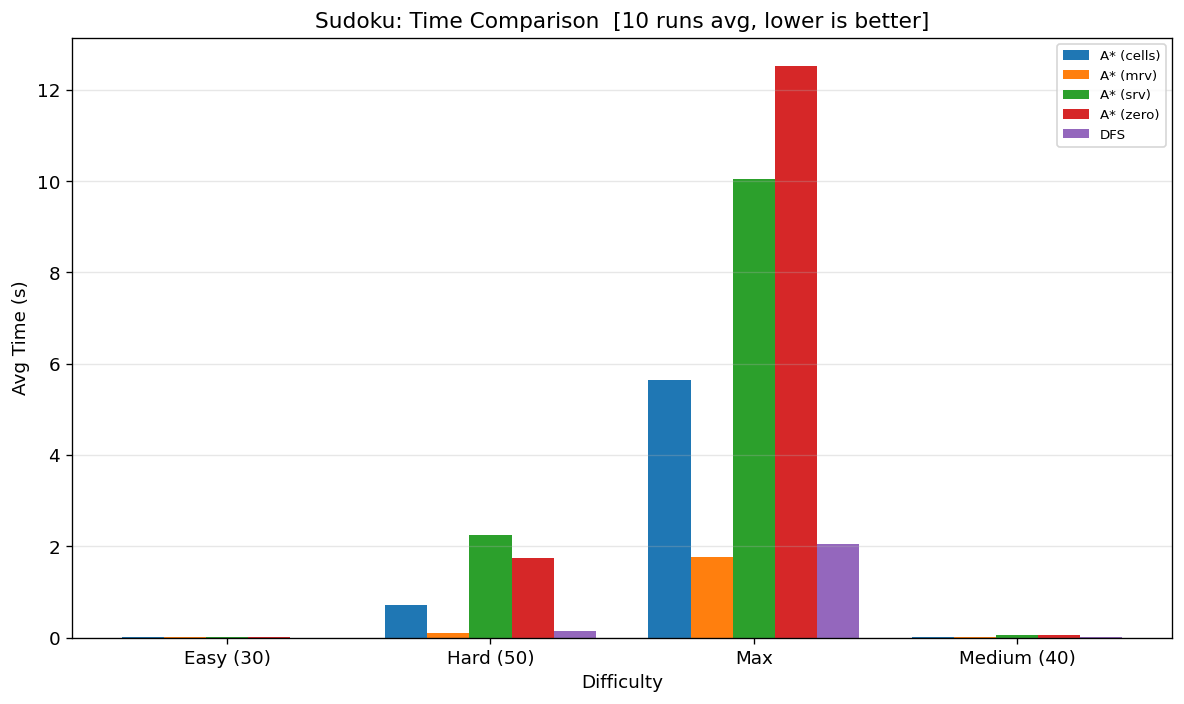

💾 Saved benchmark_output/sudoku_steps.png


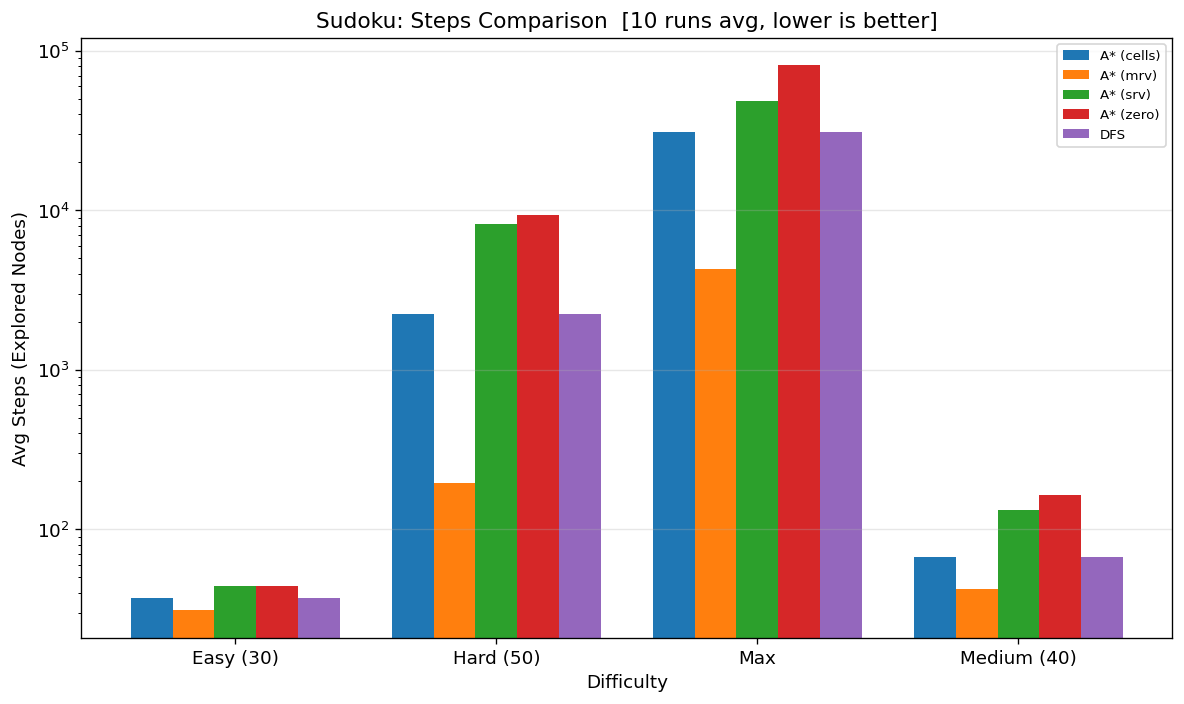

💾 Saved benchmark_output/sudoku_memory.png


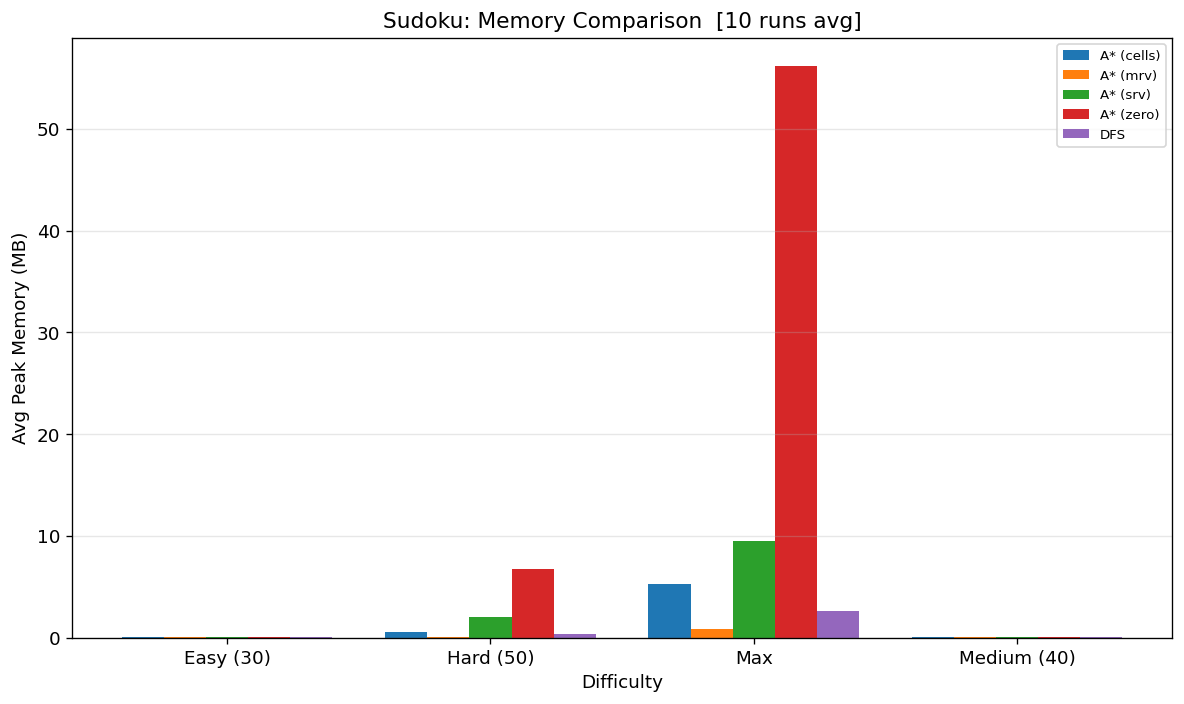

In [20]:
df_plot    = sudoku_summary.copy()
algo_names = df_plot['Algorithm'].unique()
diff_names = df_plot['Difficulty'].unique()
x          = np.arange(len(diff_names))
width      = 0.8 / len(algo_names)

# ── Bar chart: Execution Time ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
for i, algo in enumerate(algo_names):
    subset = df_plot[df_plot['Algorithm'] == algo]
    subset = subset.set_index('Difficulty').reindex(diff_names).reset_index()
    ax.bar(x + i * width, subset['Avg_Time_s'], width, label=algo)

ax.set_xlabel('Difficulty')
ax.set_ylabel('Avg Time (s)')
ax.set_title(f'Sudoku: Time Comparison  [{BENCHMARK_RUNS} runs avg, lower is better]')
ax.set_xticks(x + width * (len(algo_names) - 1) / 2)
ax.set_xticklabels(diff_names)
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/sudoku_time.png", dpi=150)
print(f"💾 Saved {RESULTS_DIR}/sudoku_time.png")
plt.show()

# ── Bar chart: Steps (log scale) ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
for i, algo in enumerate(algo_names):
    subset = df_plot[df_plot['Algorithm'] == algo]
    subset = subset.set_index('Difficulty').reindex(diff_names).reset_index()
    ax.bar(x + i * width, subset['Avg_Steps'], width, label=algo)

ax.set_xlabel('Difficulty')
ax.set_ylabel('Avg Steps (Explored Nodes)')
ax.set_title(f'Sudoku: Steps Comparison  [{BENCHMARK_RUNS} runs avg, lower is better]')
ax.set_xticks(x + width * (len(algo_names) - 1) / 2)
ax.set_xticklabels(diff_names)
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)
ax.set_yscale('log')
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/sudoku_steps.png", dpi=150)
print(f"💾 Saved {RESULTS_DIR}/sudoku_steps.png")
plt.show()

# ── Bar chart: Peak Memory ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
for i, algo in enumerate(algo_names):
    subset = df_plot[df_plot['Algorithm'] == algo]
    subset = subset.set_index('Difficulty').reindex(diff_names).reset_index()
    ax.bar(x + i * width, subset['Avg_Peak_Memory_MB'], width, label=algo)

ax.set_xlabel('Difficulty')
ax.set_ylabel('Avg Peak Memory (MB)')
ax.set_title(f'Sudoku: Memory Comparison  [{BENCHMARK_RUNS} runs avg]')
ax.set_xticks(x + width * (len(algo_names) - 1) / 2)
ax.set_xticklabels(diff_names)
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/sudoku_memory.png", dpi=150)
print(f"💾 Saved {RESULTS_DIR}/sudoku_memory.png")
plt.show()

---
## 5 · Net (Pipes) Benchmark

### 5.1 Generate Net Puzzles

Sizes: 3x3 up to 7x7.

In [21]:
NET_SIZES = [5, 10, 15, 20, 25, 30]
NUM_NET_TRIALS = 10

net_puzzles = {}  # size -> list of (grid, seed)

for size in NET_SIZES:
    puzzles = []
    for trial in range(NUM_NET_TRIALS):
        seed = 2000 + (size * 100) + trial
        grid = generate_net_puzzle(size=size, seed=seed, scramble=True)
        puzzles.append((grid, seed))
        _ = NetProblem(grid)
    net_puzzles[size] = puzzles
    print(f"  Generated {NUM_NET_TRIALS} puzzles of size {size}x{size}  "
          f"(seeds {2000 + size*100} – {2000 + size*100 + NUM_NET_TRIALS - 1})")

print("\n✅ Net puzzle generation complete.")

  Generated 10 puzzles of size 5x5  (seeds 2500 – 2509)
  Generated 10 puzzles of size 10x10  (seeds 3000 – 3009)
  Generated 10 puzzles of size 15x15  (seeds 3500 – 3509)
  Generated 10 puzzles of size 20x20  (seeds 4000 – 4009)
  Generated 10 puzzles of size 25x25  (seeds 4500 – 4509)
  Generated 10 puzzles of size 30x30  (seeds 5000 – 5009)

✅ Net puzzle generation complete.


### 5.2 Run Net Benchmarks

Tasks are submitted in **parallel across all CPU cores** (`ProcessPoolExecutor`).  
Each (algo × size × trial) task runs:
- **2 warm-up** iterations (discarded — primes caches & GC)
- **10 benchmark** iterations — results **averaged** and reported

In [22]:
net_tasks = []   # list of (meta_dict, task_spec_dict)

for size, puzzles in net_puzzles.items():
    for trial_idx, (grid, seed) in enumerate(puzzles):
        grid_json = _grid_to_json(grid, "Net")
        for algo_base_name in ALGORITHMS:
            if algo_base_name == "A*":
                for h_name, _ in NetProblem.HEURISTIC_FUNCTIONS:
                    algo_display = f"A* ({h_name})"
                    spec = {
                        "proj_dir":     _PROJ_DIR,
                        "algo_name":    "A*",
                        "problem_type": "Net",
                        "grid":         grid,
                        "heuristic":    h_name,
                        "timeout":      TIMEOUT,
                        "warmup_runs":  WARMUP_RUNS,
                        "bench_runs":   BENCHMARK_RUNS,
                        "seed":         seed,
                    }
                    meta = {
                        "algo_display": algo_display,
                        "label":        f"Net {size}x{size} trial {trial_idx}",
                        "Game":         "Net",
                        "Size":         f"{size}x{size}",
                        "Trial":        trial_idx,
                        "Algorithm":    algo_display,
                        "seed":         seed,
                        "grid_json":    grid_json,
                    }
                    net_tasks.append((meta, spec))
            else:
                spec = {
                    "proj_dir":     _PROJ_DIR,
                    "algo_name":    "DFS",
                    "problem_type": "Net",
                    "grid":         grid,
                    "heuristic":    None,
                    "timeout":      TIMEOUT,
                    "warmup_runs":  WARMUP_RUNS,
                    "bench_runs":   BENCHMARK_RUNS,
                    "seed":         seed,
                }
                meta = {
                    "algo_display": "DFS",
                    "label":        f"Net {size}x{size} trial {trial_idx}",
                    "Game":         "Net",
                    "Size":         f"{size}x{size}",
                    "Trial":        trial_idx,
                    "Algorithm":    "DFS",
                    "seed":         seed,
                    "grid_json":    grid_json,
                }
                net_tasks.append((meta, spec))

print(f"📋 Total Net tasks : {len(net_tasks)}")
print(f"   Each task = {WARMUP_RUNS} warmup + {BENCHMARK_RUNS} benchmark runs  (avg reported)")
print(f"🚀 Submitting to {NUM_WORKERS}-worker pool …\n")

net_raw = run_tasks_parallel(net_tasks)

# ── Build summary + per-run DataFrames ────────────────────────────────────────
net_results  = []
net_run_rows = []

for meta, res in net_raw:
    per_runs = res.get("per_run_results", [])

    # Per-run detail rows (warmup + benchmark)
    for run_row in per_runs:
        net_run_rows.append({
            "Game":      meta["Game"],
            "Size":      meta["Size"],
            "Trial":     meta["Trial"],
            "Algorithm": meta["Algorithm"],
            "seed":      meta["seed"],
            "grid_json": meta["grid_json"],
            **run_row,
        })

    # Task-level summary
    summary = {k: v for k, v in meta.items() if k not in _SUMMARY_DROP}
    summary.update({k: v for k, v in res.items() if k != "per_run_results"})
    net_results.append(summary)

df_net      = pd.DataFrame(net_results)
df_net_runs = pd.DataFrame(net_run_rows)

print(f"\n✅ Net benchmarks complete.")
print(f"   Summary rows  : {len(df_net)}")
print(f"   Per-run rows  : {len(df_net_runs)}  "
      f"({df_net_runs['run_type'].value_counts().to_dict() if not df_net_runs.empty else 'n/a'})")
gc.collect()

📋 Total Net tasks : 300
   Each task = 2 warmup + 10 benchmark runs  (avg reported)
🚀 Submitting to 20-worker pool …

  DFS                            | Net 5x5 trial 0                     → ✅  avg_time=0.004467s  avg_steps=26.0  (10 bench runs)
  A* (zero)                      | Net 5x5 trial 1                     → ✅  avg_time=0.006408s  avg_steps=40.0  (10 bench runs)
  A* (connectivity)              | Net 5x5 trial 1                     → ✅  avg_time=0.00713s  avg_steps=28.0  (10 bench runs)
  A* (lookahead)                 | Net 5x5 trial 0                     → ✅  avg_time=0.006727s  avg_steps=26.0  (10 bench runs)
  DFS                            | Net 5x5 trial 1                     → ✅  avg_time=0.003943s  avg_steps=28.0  (10 bench runs)
  A* (connectivity)              | Net 5x5 trial 3                     → ✅  avg_time=0.006914s  avg_steps=29.0  (10 bench runs)
  A* (zero)                      | Net 5x5 trial 3                     → ✅  avg_time=0.005965s  avg_steps=29.0  (10

0

### 5.3 Net Results Table

In [23]:
net_summary = df_net.groupby(['Size', 'Algorithm']).agg(
    Solved=('solved', 'sum'),
    Total=('solved', 'count'),
    Avg_Time_s=('time_s', 'mean'),
    Avg_Steps=('steps', 'mean'),
    Avg_Path_Length=('path_length', 'mean'),
    Avg_Peak_Memory_MB=('peak_memory_mb', 'mean'),
).reset_index()

net_summary['Avg_Time_s'] = net_summary['Avg_Time_s'].round(4)
net_summary['Avg_Steps'] = net_summary['Avg_Steps'].round(0).astype('Int64')
net_summary['Avg_Path_Length'] = net_summary['Avg_Path_Length'].round(1)
net_summary['Avg_Peak_Memory_MB'] = net_summary['Avg_Peak_Memory_MB'].round(2)

print("=" * 100)
print(f"NET BENCHMARK RESULTS  (averaged over {NUM_NET_TRIALS} trials)")
print("=" * 100)
print(tabulate(net_summary, headers='keys', tablefmt='github', showindex=False))

NET BENCHMARK RESULTS  (averaged over 10 trials)
| Size   | Algorithm         |   Solved |   Total |   Avg_Time_s |   Avg_Steps |   Avg_Path_Length |   Avg_Peak_Memory_MB |
|--------|-------------------|----------|---------|--------------|-------------|-------------------|----------------------|
| 10x10  | A* (cells)        |       10 |      10 |       0.0222 |         110 |              99.9 |                 0.5  |
| 10x10  | A* (connectivity) |       10 |      10 |       0.0641 |         110 |              99.9 |                 0.5  |
| 10x10  | A* (lookahead)    |       10 |      10 |       0.0293 |         107 |              99.9 |                 0.49 |
| 10x10  | A* (zero)         |       10 |      10 |       0.0238 |         121 |              99.9 |                 0.48 |
| 10x10  | DFS               |       10 |      10 |       0.0188 |         110 |              99.9 |                 0.49 |
| 15x15  | A* (cells)        |       10 |      10 |       0.0758 |         288 |   

### 5.4 Net Visualizations

💾 Saved benchmark_output/net_time.png


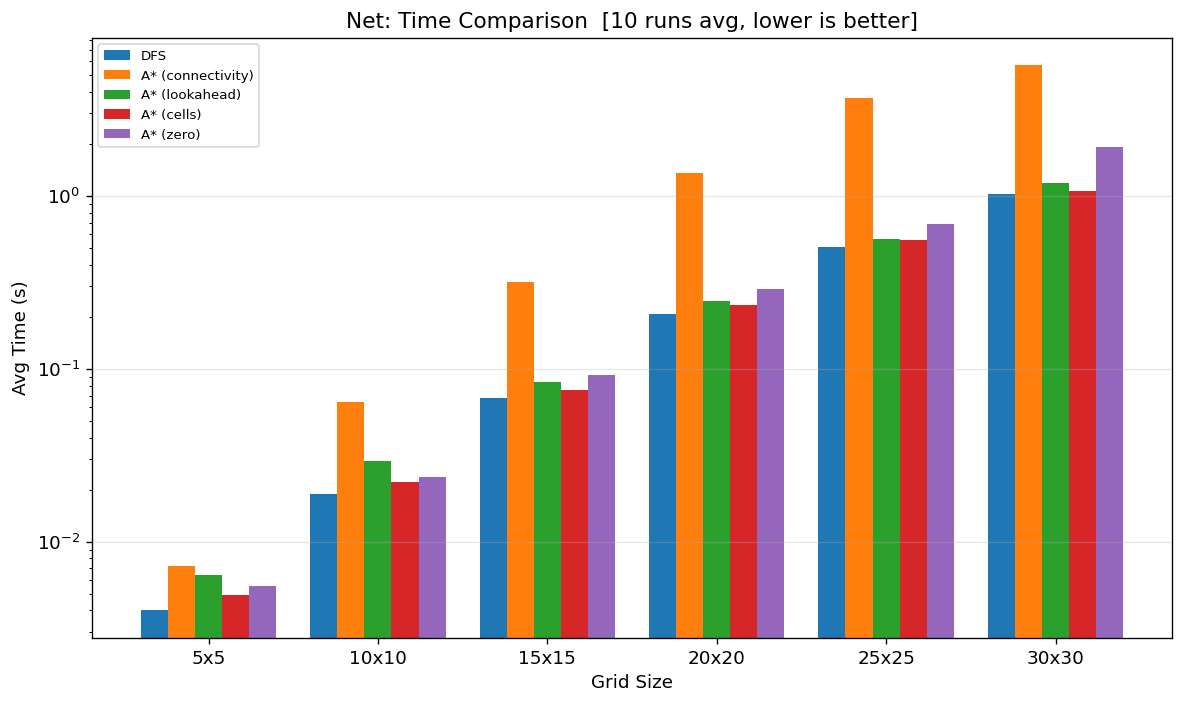

💾 Saved benchmark_output/net_steps.png


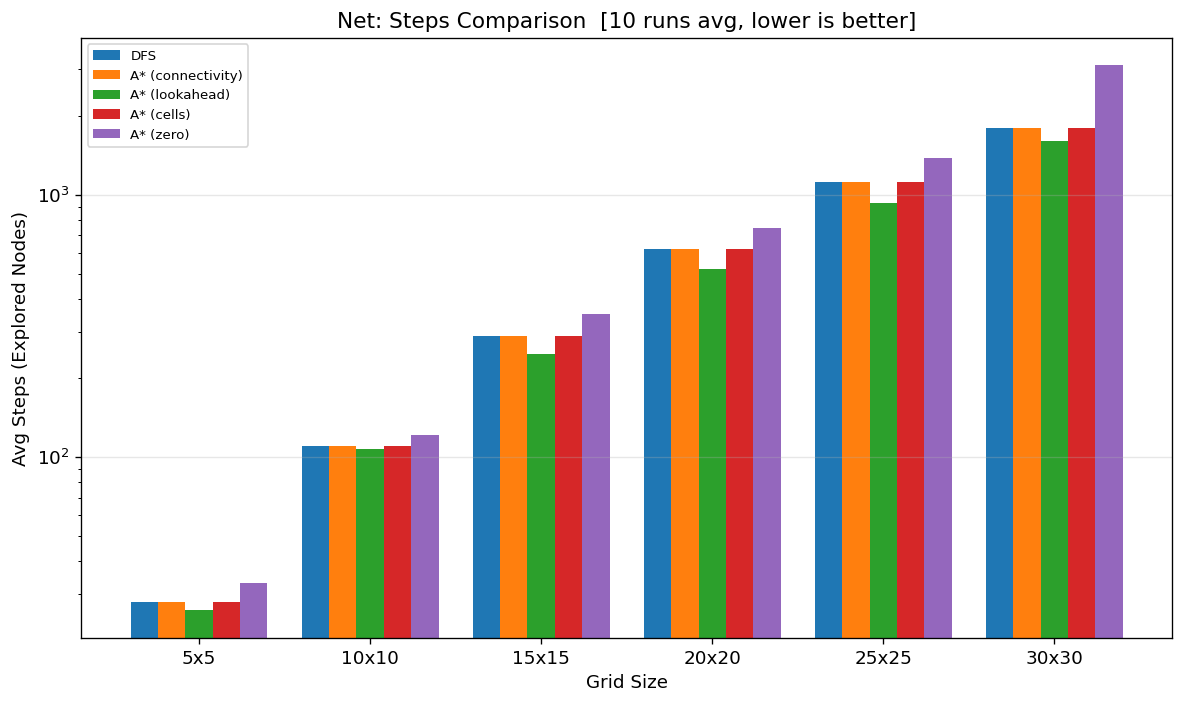

💾 Saved benchmark_output/net_memory.png


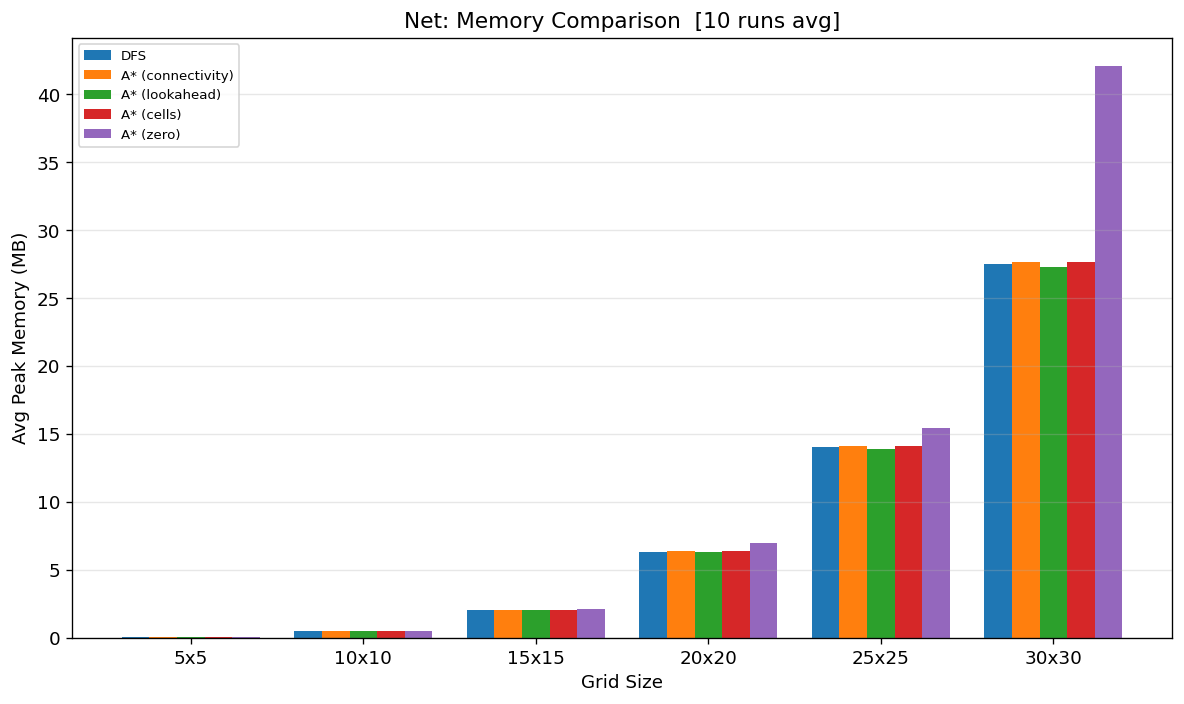

In [24]:
df_plot_net = net_summary.copy()
df_plot_net['SizeInt'] = df_plot_net['Size'].apply(lambda s: int(s.split('x')[0]))
df_plot_net = df_plot_net.sort_values('SizeInt')

algo_names_net = df_plot_net['Algorithm'].unique()
size_names     = df_plot_net['Size'].unique()
x              = np.arange(len(size_names))
width          = 0.8 / len(algo_names_net)

# ── Bar chart: Time (log scale) ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
for i, algo in enumerate(algo_names_net):
    subset = df_plot_net[df_plot_net['Algorithm'] == algo]
    subset = subset.set_index('Size').reindex(size_names).reset_index()
    ax.bar(x + i * width, subset['Avg_Time_s'], width, label=algo)

ax.set_xlabel('Grid Size')
ax.set_ylabel('Avg Time (s)')
ax.set_title(f'Net: Time Comparison  [{BENCHMARK_RUNS} runs avg, lower is better]')
ax.set_xticks(x + width * (len(algo_names_net) - 1) / 2)
ax.set_xticklabels(size_names)
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)
ax.set_yscale('log')
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/net_time.png", dpi=150)
print(f"💾 Saved {RESULTS_DIR}/net_time.png")
plt.show()

# ── Bar chart: Steps (log scale) ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
for i, algo in enumerate(algo_names_net):
    subset = df_plot_net[df_plot_net['Algorithm'] == algo]
    subset = subset.set_index('Size').reindex(size_names).reset_index()
    ax.bar(x + i * width, subset['Avg_Steps'], width, label=algo)

ax.set_xlabel('Grid Size')
ax.set_ylabel('Avg Steps (Explored Nodes)')
ax.set_title(f'Net: Steps Comparison  [{BENCHMARK_RUNS} runs avg, lower is better]')
ax.set_xticks(x + width * (len(algo_names_net) - 1) / 2)
ax.set_xticklabels(size_names)
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)
ax.set_yscale('log')
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/net_steps.png", dpi=150)
print(f"💾 Saved {RESULTS_DIR}/net_steps.png")
plt.show()

# ── Bar chart: Peak Memory ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
for i, algo in enumerate(algo_names_net):
    subset = df_plot_net[df_plot_net['Algorithm'] == algo]
    subset = subset.set_index('Size').reindex(size_names).reset_index()
    ax.bar(x + i * width, subset['Avg_Peak_Memory_MB'], width, label=algo)

ax.set_xlabel('Grid Size')
ax.set_ylabel('Avg Peak Memory (MB)')
ax.set_title(f'Net: Memory Comparison  [{BENCHMARK_RUNS} runs avg]')
ax.set_xticks(x + width * (len(algo_names_net) - 1) / 2)
ax.set_xticklabels(size_names)
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/net_memory.png", dpi=150)
print(f"💾 Saved {RESULTS_DIR}/net_memory.png")
plt.show()

## 6 · Combined Results / Export

Saves **four levels of detail** to `benchmark_output/`:

| File | Rows | Content |
|---|---|---|
| `benchmark_results_raw.csv` | 1 per task | task-level avg summary |
| `sudoku_summary.csv` / `net_summary.csv` | 1 per (difficulty/size × algo) | grouped averages |
| `sudoku_runs_detail.csv` / `net_runs_detail.csv` | 1 per individual run | warmup & benchmark runs with **seed + grid_json** |
| `all_runs_detail.csv` | combined | both games, all runs |

In [25]:
df_all = pd.concat([df_sudoku, df_net], ignore_index=True)

df_all['Puzzle'] = df_all.apply(
    lambda r: f"Sudoku {r['Difficulty']}" if r['Game'] == 'Sudoku'
              else f"Net {r['Size']}",
    axis=1,
)

# ── Combine per-run tables ────────────────────────────────────────────────────
df_all_runs = pd.concat([df_sudoku_runs, df_net_runs], ignore_index=True)

# ── Save raw summary CSVs ─────────────────────────────────────────────────────
raw_path = f"{RESULTS_DIR}/benchmark_results_raw.csv"
df_all.to_csv(raw_path, index=False)
df_all.to_csv("benchmark_results.csv", index=False)
print(f"💾 Summary (all games)     → {raw_path}")
print(f"💾 Summary (root copy)     → benchmark_results.csv")

# ── Save per-game summary CSVs ─────────────────────────────────────────────────
sudoku_sum_path = f"{RESULTS_DIR}/sudoku_summary.csv"
net_sum_path    = f"{RESULTS_DIR}/net_summary.csv"
sudoku_summary.to_csv(sudoku_sum_path, index=False)
net_summary.to_csv(net_sum_path,       index=False)
print(f"💾 Sudoku grouped summary  → {sudoku_sum_path}")
print(f"💾 Net grouped summary     → {net_sum_path}")

# ── Save per-run detail CSVs (seed + grid + every individual run) ─────────────
sudoku_runs_path = f"{RESULTS_DIR}/sudoku_runs_detail.csv"
net_runs_path    = f"{RESULTS_DIR}/net_runs_detail.csv"
all_runs_path    = f"{RESULTS_DIR}/all_runs_detail.csv"
df_sudoku_runs.to_csv(sudoku_runs_path, index=False)
df_net_runs.to_csv(net_runs_path,       index=False)
df_all_runs.to_csv(all_runs_path,       index=False)
print(f"💾 Sudoku per-run detail   → {sudoku_runs_path}  ({len(df_sudoku_runs)} rows)")
print(f"💾 Net per-run detail      → {net_runs_path}  ({len(df_net_runs)} rows)")
print(f"💾 All games per-run       → {all_runs_path}  ({len(df_all_runs)} rows)")

# ── Pretty-print head ──────────────────────────────────────────────────────────
_display_cols = ["Game", "Puzzle", "Algorithm", "seed", "run_type", "run_idx",
                 "solved", "timed_out", "time_s", "steps", "path_length", "peak_memory_mb"]
_show = [c for c in _display_cols if c in df_all_runs.columns]
print(f"\n📊 Per-run sample  (first 10 of {len(df_all_runs)} rows):")
print(tabulate(df_all_runs[_show].head(10), headers='keys', tablefmt='psql', showindex=False))

💾 Summary (all games)     → benchmark_output/benchmark_results_raw.csv
💾 Summary (root copy)     → benchmark_results.csv
💾 Sudoku grouped summary  → benchmark_output/sudoku_summary.csv
💾 Net grouped summary     → benchmark_output/net_summary.csv
💾 Sudoku per-run detail   → benchmark_output/sudoku_runs_detail.csv  (720 rows)
💾 Net per-run detail      → benchmark_output/net_runs_detail.csv  (3600 rows)
💾 All games per-run       → benchmark_output/all_runs_detail.csv  (4320 rows)

📊 Per-run sample  (first 10 of 4320 rows):
+--------+-------------+--------+------------+-----------+----------+-------------+----------+---------+---------------+------------------+
| Game   | Algorithm   |   seed | run_type   |   run_idx | solved   | timed_out   |   time_s |   steps |   path_length |   peak_memory_mb |
|--------+-------------+--------+------------+-----------+----------+-------------+----------+---------+---------------+------------------|
| Sudoku | DFS         |   1000 | warmup     |        

## 7 · Convert Notebook → Standalone Python Script

Converts `run.ipynb` to `benchmark_script.py`.

> **Note (Windows / macOS):** The converted script uses `ProcessPoolExecutor`.  
> Wrap the parallel sections in `if __name__ == "__main__":` before running on  
> platforms that use the `spawn` start method.

In [26]:
import subprocess

nb_path  = "run.ipynb"
out_name = "benchmark_script"   # output will be benchmark_script.py

result = subprocess.run(
    ["jupyter", "nbconvert", "--to", "script", nb_path, "--output", out_name],
    capture_output=True, text=True,
)

if result.returncode == 0:
    print(f"✅ Notebook exported  →  {out_name}.py")
    print(f"   Run with :  python {out_name}.py")
    if result.stdout.strip():
        print(result.stdout.strip())
else:
    print("❌ Conversion failed:")
    print(result.stderr)

❌ Conversion failed:
usage: jupyter [-h] [--version] [--config-dir] [--data-dir] [--runtime-dir]
               [--paths] [--json] [--debug]
               [subcommand]

Jupyter: Interactive Computing

positional arguments:
  subcommand     the subcommand to launch

options:
  -h, --help     show this help message and exit
  --version      show the versions of core jupyter packages and exit
  --config-dir   show Jupyter config dir
  --data-dir     show Jupyter data dir
  --runtime-dir  show Jupyter runtime dir
  --paths        show all Jupyter paths. Add --json for machine-readable
                 format.
  --json         output paths as machine-readable json
  --debug        output debug information about paths

Available subcommands: kernel kernelspec migrate run troubleshoot

Jupyter command `jupyter-nbconvert` not found.

